In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2



## bài 1 phân đoạn ảnh dựa trên ngưỡng _ thresholding 

 Ảnh đã đọc thành công!


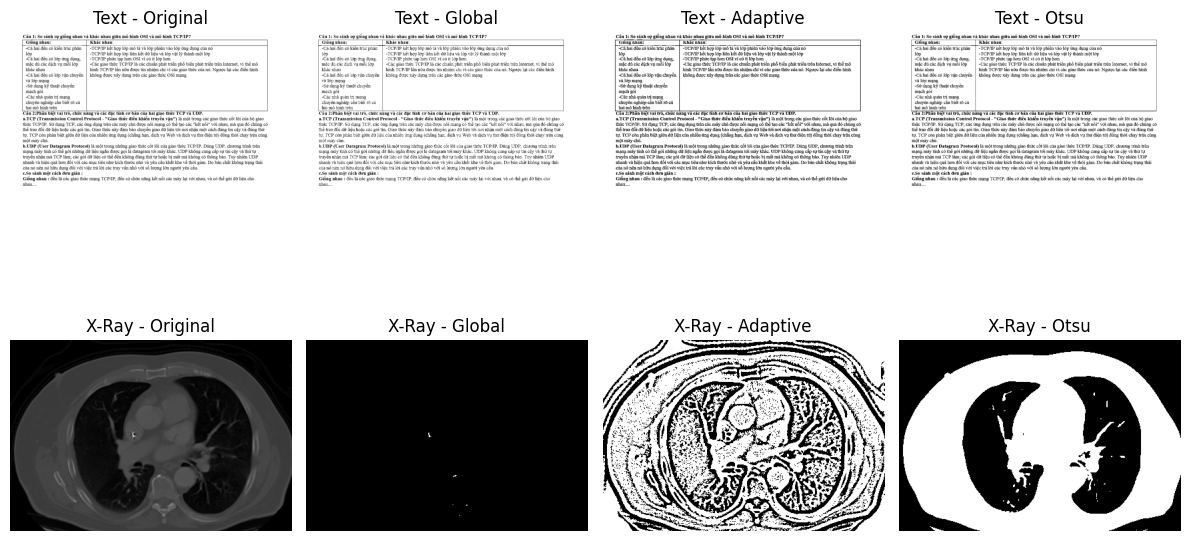

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh văn bản (OCR) và ảnh X-quang (medical image)
img_text = cv2.imread("img\\text.png", cv2.IMREAD_GRAYSCALE)
img_xquang = cv2.imread("img\\Lung MRI (100).png", cv2.IMREAD_GRAYSCALE)

# Kiểm tra ảnh có đọc được không
if img_text is None or img_xquang is None:
    print(" Lỗi: Không đọc được ảnh. Vui lòng kiểm tra lại đường dẫn!")
else:
    print(" Ảnh đã đọc thành công!")

# Hàm xử lý ngưỡng cho một ảnh
def apply_thresholds(img):
    _, global_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    adaptive_thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                            cv2.THRESH_BINARY, 11, 2)
    _, otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return [img, global_thresh, adaptive_thresh, otsu_thresh]

# Áp dụng cho cả 2 ảnh
results_text = apply_thresholds(img_text)
results_xquang = apply_thresholds(img_xquang)

titles = ['Original', 'Global', 'Adaptive', "Otsu"]

# Hiển thị so sánh 2 ảnh song song
plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.title(f"Text - {titles[i]}")
    plt.imshow(results_text[i], cmap='gray')
    plt.axis('off')

    plt.subplot(2, 4, i+5)
    plt.title(f"X-Ray - {titles[i]}")
    plt.imshow(results_xquang[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
import numpy as np

# Hàm tính IoU
def calculate_iou(pred, mask):
    pred_bin = (pred > 0).astype('uint8')
    mask_bin = (mask > 0).astype('uint8')
    
    intersection = np.logical_and(pred_bin, mask_bin).sum()
    union = np.logical_or(pred_bin, mask_bin).sum()

    return intersection / union if union != 0 else 0

# --- GIẢ LẬP GROUND TRUTH ---
gt_text = results_text[3]      # Otsu làm Ground Truth cho ảnh văn bản
gt_xray = results_xquang[2]    # Adaptive làm Ground Truth cho ảnh X-ray

# --- TÍNH IoU CHO ẢNH VĂN BẢN ---
print("\n=== IoU cho ảnh Văn Bản (Text) so với Ground Truth Otsu ===")
print("Global vs GT:", calculate_iou(results_text[1], gt_text))
print("Adaptive vs GT:", calculate_iou(results_text[2], gt_text))
print("Otsu vs GT:", calculate_iou(results_text[3], gt_text))

# --- TÍNH IoU CHO ẢNH X-RAY ---
print("\n=== IoU cho ảnh X-Ray so với Ground Truth Adaptive ===")
print("Global vs GT:", calculate_iou(results_xquang[1], gt_xray))
print("Adaptive vs GT:", calculate_iou(results_xquang[2], gt_xray))
print("Otsu vs GT:", calculate_iou(results_xquang[3], gt_xray))



=== IoU cho ảnh Văn Bản (Text) so với Ground Truth Otsu ===
Global vs GT: 0.9825201089167788
Adaptive vs GT: 0.983337951506002
Otsu vs GT: 1.0

=== IoU cho ảnh X-Ray so với Ground Truth Adaptive ===
Global vs GT: 0.0003356455582904453
Adaptive vs GT: 1.0
Otsu vs GT: 0.5308050927184161


###  Nhận xét về lựa chọn phương pháp phân ngưỡng (Thresholding)

| Tình huống ảnh | Nên dùng **Global Threshold** | Nên dùng **Adaptive Threshold** | Nên dùng **Otsu’s Method** |
|----------------|------------------------------|----------------------------------|-----------------------------|
| Ảnh có **ánh sáng đồng đều**, nền và tiền cảnh tách biệt rõ (ví dụ: chữ đen trên nền trắng) |  Phù hợp |  Không cần thiết |  Tốt nếu muốn chọn ngưỡng tự động |
| Ảnh có **nhiễu sáng**, vùng sáng tối không đồng đều (ảnh tài liệu bị bóng, giấy nhàu) |  Không hiệu quả |  Tối ưu nhất |  Có thể sai nếu histogram không rõ ràng |
| Ảnh có **độ tương phản thấp hoặc nhiều mức xám** (ảnh y tế như X-ray, MRI, CT-Scan) |  Thất bại |  Tạm ổn nhưng có thể mất chi tiết |  Tốt nếu ảnh chỉ có 2 lớp foreground & background |

---

###  Kết luận

- **Otsu’s Method** hiệu quả nhất khi ảnh có **histogram tách biệt thành hai đỉnh rõ ràng**, điển hình như *ảnh văn bản đen trắng* hoặc *biển báo*.
- **Adaptive Thresholding** phù hợp khi ảnh có **độ sáng thay đổi theo vùng**, như *ảnh chụp thực tế* hoặc *ảnh y tế (X-ray, CT)*.
- **Global Threshold** chỉ nên dùng khi **ta biết chắc ngưỡng cố định phù hợp cho toàn ảnh**.

 Vì vậy, **ảnh văn bản (OCR) nên dùng Otsu hoặc Adaptive**, còn **ảnh X-quang nên ưu tiên Adaptive**.


# bài 2 phân đoạn ảnh dựa trên vùng - region growing 

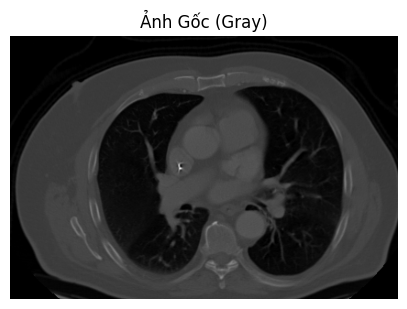

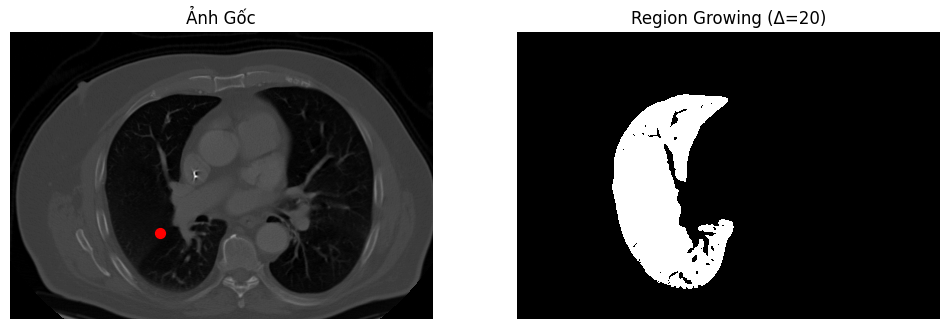

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ---- 1. Đọc ảnh (có thể là ảnh xám hoặc chuyển từ ảnh màu) ----
img = cv2.imread("img/Lung MRI (100).png", cv2.IMREAD_GRAYSCALE)  # Đổi bằng ảnh của bạn

plt.figure(figsize=(5,5))
plt.title("Ảnh Gốc (Gray)")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

# ---- 2. Hàm Region Growing ----
def region_growing(image, seed, threshold=10):
    """
    image: ảnh xám
    seed: (x, y) toạ độ điểm bắt đầu
    threshold: ngưỡng Δ
    """
    h, w = image.shape
    mask = np.zeros_like(image, dtype=np.uint8)  # lưu vùng phân đoạn

    seed_value = image[seed[1], seed[0]]  # cường độ tại seed
    q = deque([seed])
    mask[seed[1], seed[0]] = 255

    # 8-neighbors
    neighbors = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while q:
        x, y = q.popleft()
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h:  # kiểm tra biên ảnh
                if mask[ny, nx] == 0:  # chưa được xét
                    if abs(int(image[ny, nx]) - int(seed_value)) < threshold:
                        mask[ny, nx] = 255
                        q.append((nx, ny))

    return mask

# ---- 3. Chọn seed và ngưỡng Δ ----
seed = (150, 200)      # đổi tuỳ ảnh (click bằng mắt thường)
delta = 20             # Δ càng nhỏ -> vùng nhỏ; ĐN càng lớn -> vùng rộng

mask = region_growing(img, seed, delta)

# ---- 4. Hiển thị kết quả ----
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Ảnh Gốc")
plt.imshow(img, cmap='gray')
plt.scatter([seed[0]], [seed[1]], c='r', s=50)  # đánh dấu seed
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f"Region Growing (Δ={delta})")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.show()


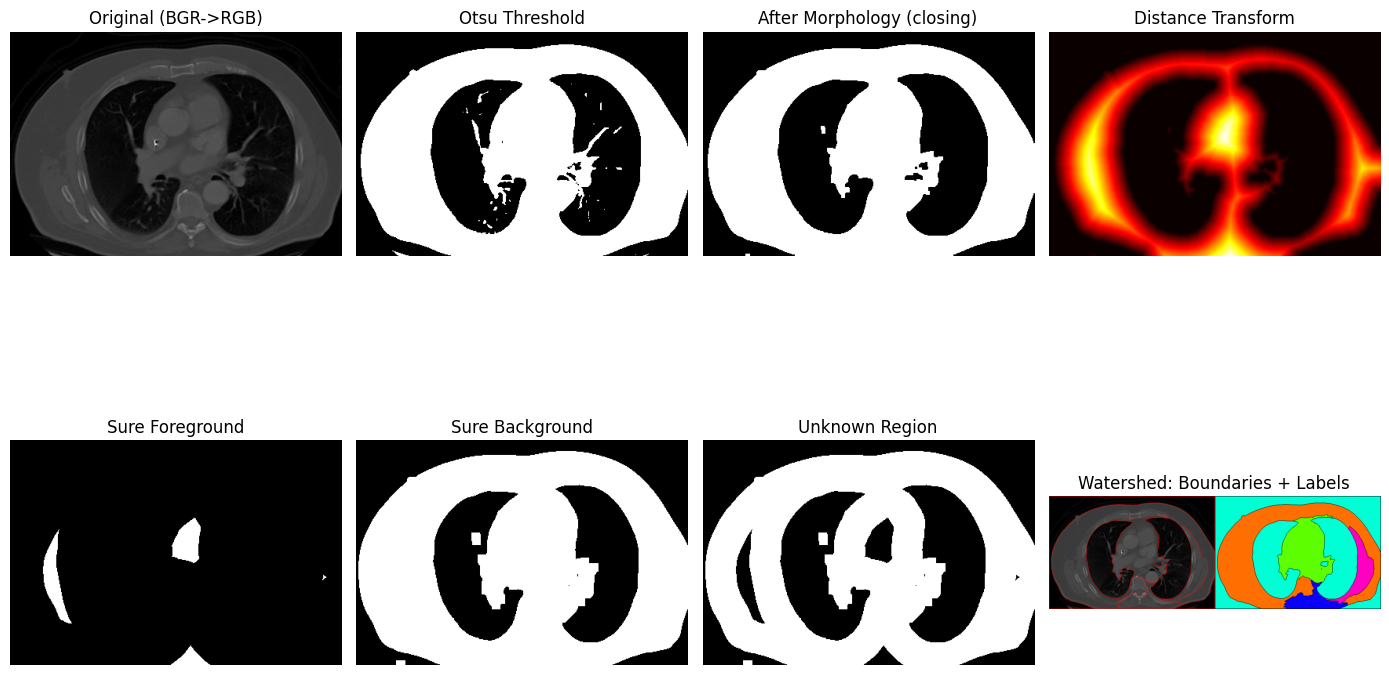

In [ ]:
# ...existing code...
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---- Watershed segmentation ----
img_path = "img/Lung MRI (100).png"  # Windows path inside repo
img_color = cv2.imread(img_path)
if img_color is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh: {img_path}")

img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# 1) Chuyển sang nhị phân bằng Otsu
ret, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2) Morphological opening/closing để loại nhiễu
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=1)

# 3) Sure background (dilate) và sure foreground (distance transform + threshold)
sure_bg = cv2.dilate(closing, kernel, iterations=3)
dist_transform = cv2.distanceTransform(closing, cv2.DIST_L2, 5)
ret2, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 4) Unknown region = sure_bg - sure_fg
unknown = cv2.subtract(sure_bg, sure_fg)

# 5) Marker labeling cho watershed
ret3, markers = cv2.connectedComponents(sure_fg)
# Thêm 1 để không cho background là 0 (watershed yêu cầu)
markers = markers + 1
# Đánh dấu vùng unknown bằng 0
markers[unknown == 255] = 0

# 6) Áp dụng watershed (ảnh 3 kênh)
img_ws = img_color.copy()
markers = cv2.watershed(img_ws, markers)    
# Biên bờ sẽ có marker == -1, tô đỏ
img_ws[markers == -1] = [0, 0, 255]

# Tạo ảnh màu cho các nhãn (chỉ để minh họa)
label_hue = np.uint8(179 * (markers.astype(np.float32) / np.max(markers)))
label_hue[markers <= 0] = 0
blank_ch = 255 * np.ones_like(label_hue)
labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
labeled_img[label_hue == 0] = 0

# Hiển thị kết quả
# Hiển thị kết quả
plt.figure(figsize=(14,10))

plt.subplot(2,4,1)
plt.title("Original (BGR->RGB)")
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,4,2)
plt.title("Otsu Threshold")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(2,4,3)
plt.title("After Morphology (closing)")
plt.imshow(closing, cmap='gray')
plt.axis('off')

plt.subplot(2,4,4)
plt.title("Distance Transform")
plt.imshow(dist_transform, cmap='hot')
plt.axis('off')

# Tách riêng từng ảnh FG / BG / Unknown
plt.subplot(2,4,5)
plt.title("Sure Foreground")
plt.imshow(sure_fg, cmap='gray')
plt.axis('off')

plt.subplot(2,4,6)
plt.title("Sure Background")
plt.imshow(sure_bg, cmap='gray')
plt.axis('off')

plt.subplot(2,4,7)
plt.title("Unknown Region")
plt.imshow(unknown, cmap='gray')
plt.axis('off')

plt.subplot(2,4,8)
plt.title("Watershed: Boundaries + Labels")
combined = np.hstack([cv2.cvtColor(img_ws, cv2.COLOR_BGR2RGB), labeled_img])
plt.imshow(combined)
plt.axis('off')

plt.tight_layout()
plt.show()


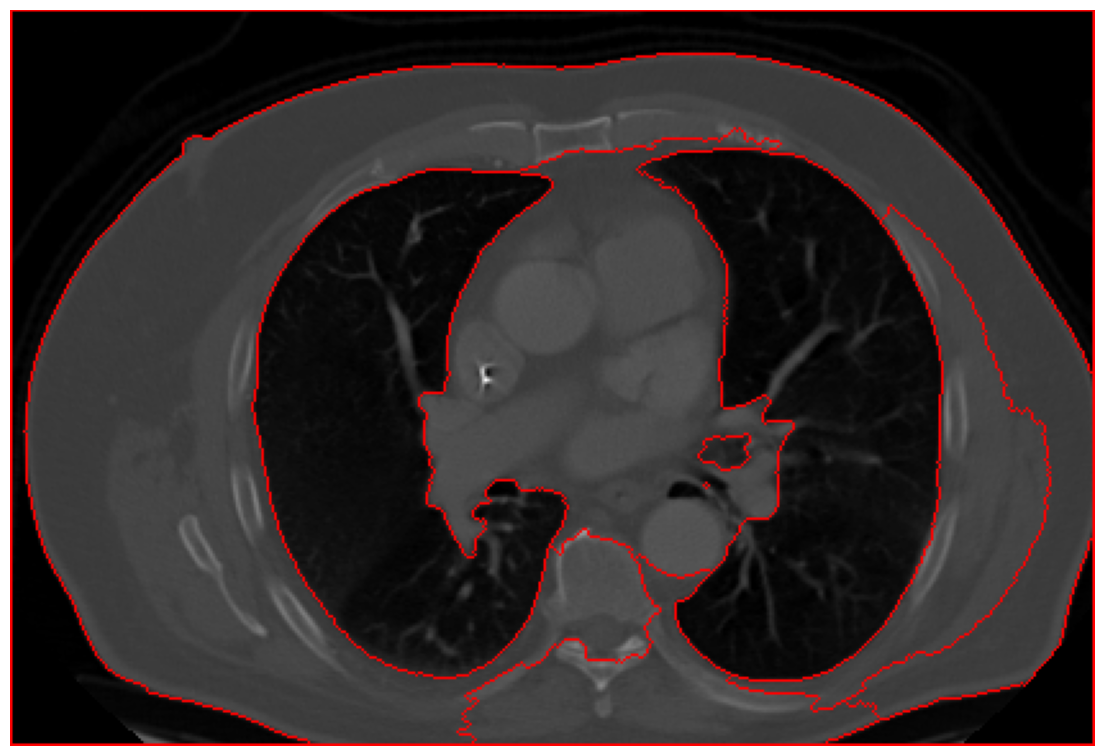

In [31]:
plt.figure(figsize=(14,10))
img_ws=cv2.cvtColor(img_ws, cv2.COLOR_BGR2RGB)
plt.imshow(img_ws)
plt.axis('off')
plt.show()


# Phân tích kết quả Watershed (một cách chi tiết)

Dưới đây là phân tích theo từng ảnh (từ trái → phải, trên → dưới) như hiển thị trong figure.

---

## 1. Original (BGR -> RGB)
**Mục đích:** Hiển thị ảnh gốc (chuyển màu BGR → RGB để matplotlib hiển thị đúng).  
**Ý nghĩa quan sát:** cho ta bối cảnh ban đầu: cấu trúc phổi, mô mềm, các vùng sáng/tối. Quan sát này quan trọng để hiểu **vị trí** và **hình dạng** của các đối tượng cần tách (ví dụ vùng mô, lỗ khí).  
**Gợi ý:** kiểm tra tương phản / nhiễu ở ảnh gốc để quyết định tiền xử lý (độ sáng, histogram equalization nếu cần).

---

## 2. Otsu Threshold
**Mục đích:** Chuyển ảnh sang nhị phân tự động bằng Otsu để tách foreground (vùng quan tâm) và background.  
**Ý nghĩa quan sát:** ảnh nhị phân cho thấy phần nào được coi là vật thể theo ngưỡng toàn cục. Ở ảnh này ta thấy:  
- Vùng phổi (đen) khác biệt so với mô xung quanh (trắng).  
- Một số nhiễu nhỏ/đốm vẫn xuất hiện trong vùng foreground.  
**Gợi ý:** nếu Otsu cho kết quả quá thô, cân nhắc `adaptiveThreshold` hoặc cân bằng histogram trước khi threshold.

---

## 3. After Morphology (closing)
**Mục đích:** Dùng opening/closing để loại nhiễu (opening) và lấp lỗ nhỏ (closing), giúp mask sạch hơn trước bước tiếp.  
**Ý nghĩa quan sát:** so với Otsu, vùng trắng (vật thể) đã được làm liền mạch hơn, lỗ nhỏ bên trong vật thể được lấp lại, đốm rời được giảm bớt. Đây là bước quan trọng để tránh marker sai cho bước sau.  
**Gợi ý tinh chỉnh:** thay đổi kernel (hình elip/rect), hoặc thay đổi `iterations` nếu thấy vật thể bị mất chi tiết khi kernel quá lớn.

---

## 4. Distance Transform
**Mục đích:** Tính khoảng cách từ mỗi pixel foreground đến nền gần nhất — kết quả là một bản đồ giá trị (heatmap).  
**Ý nghĩa quan sát:** các vùng sáng nhất (giá trị lớn) là **lõi** của các vật thể (nơi xa nền nhất). Đây sẽ là nguồn để tạo “sure foreground” (marker lõi).  
**Gợi ý:** thay đổi tham số threshold trên dist_transform (ví dụ 0.4–0.7 * max) để điều chỉnh kích thước marker lõi; nếu marker quá nhỏ hoặc quá lớn, watershed sẽ không tách tốt.

---

## 5. Sure Foreground
**Mục đích:** Ảnh nhị phân chỉ giữ lại các pixel có giá trị distance lớn hơn ngưỡng (ví dụ ≥ 0.7 * max).  
**Ý nghĩa quan sát:** Hiển thị các “hạt giống” (seeds) nằm sâu trong mỗi vật thể — những vùng này được `connectedComponents` gán nhãn cố định. Nếu sure_fg quá nhỏ → markers không đại diện tốt cho đối tượng; nếu quá lớn → markers có thể chồng lên nhau.  
**Gợi ý:** điều chỉnh ngưỡng (ví dụ 0.4–0.7) tùy kích thước vật thể.

---

## 6. Sure Background
**Mục đích:** Tạo bằng cách dilate mask đã được xử lý (closing) để phóng to vùng object → vùng mở rộng này dùng để xác định background chắc chắn.  
**Ý nghĩa quan sát:** sure_bg thường bao phủ vùng rìa, làm phẳng các lỗ, và đảm bảo vùng nền được nhận biết rộng rãi. Quan trọng là sure_bg phải bao phủ tốt để khi trừ sure_fg ra ta thu được vùng unknown hợp lý.  
**Gợi ý:** tăng giảm số lần `dilate` để làm sure_bg rộng hơn/nhỏ hơn; tránh dilate quá mức làm mất tách biệt giữa các object khác nhau.

---

## 7. Unknown Region
**Mục đích:** `unknown = sure_bg - sure_fg` — vùng nằm giữa sure_fg và sure_bg, tức là phần rìa **chưa xác định** (có thể là biên của vật thể hoặc phần nối giữa hai vật thể).  
**Ý nghĩa quan sát:** đây chính là phần Watershed **sẽ quyết định** (gán cho nhãn nào) dựa trên phép “đổ nước” từ các marker. Vùng unknown càng hẹp thì watershed càng ít việc; nếu vùng unknown quá lớn thì dễ gây nhầm lẫn.  
**Gợi ý:** nếu unknown quá rộng/không hợp lý → điều chỉnh kích thước marker (sure_fg) hoặc mức dilate cho sure_bg.

---

## 8. Watershed: Boundaries + Colored Labels
**Mục đích:** Chạy `cv2.watershed` với `markers` đã chuẩn bị → thu `markers` mới, vẽ biên (marker == -1) và màu hóa các label để trực quan.  
**Ý nghĩa quan sát:**  
- Ảnh bên trái (overlay) cho thấy **đường biên đỏ** được vẽ trên ảnh gốc — xác định nơi Watershed tách.  
- Ảnh bên phải (colored labels) minh họa **mỗi vùng được gán một màu** khác nhau (mỗi nhãn tương ứng một vùng).  
Từ đây ta có thể kiểm tra xem watershed có tách đúng các cấu trúc mong muốn (ví dụ tách các khoang phổi, phân biệt mô mềm, v.v.) hay không.  
**Gợi ý hậu xử lý:** lọc label theo diện tích/chu vi, nối/split thêm, hoặc dùng mask kết hợp với domain knowledge (ví dụ ROI lồng ngực) để bỏ label không mong muốn.

---

## Kết luận & khuyến nghị tổng quát
- Pipeline Otsu → Morphology → Distance Transform → Markers → Watershed là **một workflow chuẩn và hiệu quả** để tách các đối tượng dính nhau.  
- Những thông số then chốt cần tinh chỉnh cho ảnh của bạn:
  - Kích thước `kernel` và `iterations` cho opening/closing/dilate.
  - Ngưỡng trên `dist_transform` để lấy `sure_fg` (ví dụ 0.4–0.7 * max).  
  - Lọc kết quả cuối cùng theo diện tích/chu vi để loại nhiễu.  
- Nếu mục tiêu là **tách những object chạm nhau rất mạnh** (rìa mịn, tiếp xúc lớn), cân nhắc:
  - Thay đổi phương pháp marker (ví dụ watershed kèm gradient), hoặc
  - Kết hợp với học máy/instance segmentation nếu hình dạng quá phức tạp.

---

### Ghi chú: các lỗi thường gặp và cách khắc phục nhanh
- **Marker quá nhỏ → một vật thể không có marker → không được tách:** giảm ngưỡng dist_transform.  
- **Markers dính nhau (thiếu tách) → kết quả ít region:** tăng ngưỡng dist_transform hoặc tăng `iterations` cho opening để tách tốt hơn trước khi đo khoảng cách.  
- **Too much dilation → sure_bg phủ hết vùng → unknown quá rộng:** giảm iterations của dilation.  

---

Nếu bạn muốn mình xuất đoạn này thành một cell `Markdown` đã format sẵn trong file `.ipynb` (tạo file notebook với cell này) thì gửi xác nhận — mình sẽ chèn nội dung tương thích cho bạn.


### Nhận xét về vai trò của tiền xử lý (Morphology, Distance Transform)

Các bước tiền xử lý như **morphological operations** (dilation, erosion, opening, closing) và **distance transform** đóng vai trò đặc biệt quan trọng trong việc cải thiện chất lượng ảnh trước khi thực hiện các bước phân tích chính.  
Cụ thể:

- **Morphology** giúp loại bỏ nhiễu, làm mượt biên, tách hoặc nối các vùng ảnh một cách có kiểm soát. Điều này giúp cấu trúc đối tượng trở nên rõ ràng hơn, giảm sai lệch khi phân đoạn.
- **Distance Transform** chuyển đổi ảnh nhị phân thành bản đồ khoảng cách, giúp làm nổi bật tâm hoặc cấu trúc hình học của đối tượng. Kết quả này thường được dùng làm đầu vào cho các thuật toán nâng cao như watershed hoặc skeletonization.

Nhờ những bước tiền xử lý này, các thuật toán phía sau **hoạt động ổn định hơn, giảm lỗi sai và cho kết quả chính xác hơn**. Có thể nói rằng nếu bỏ qua hoặc thực hiện sơ sài giai đoạn tiền xử lý thì hiệu suất của toàn bộ pipeline sẽ bị ảnh hưởng đáng kể.


# bài 4


Số vùng liên thông: 36
Đã lưu 30 đối tượng vào cells_detected.csv


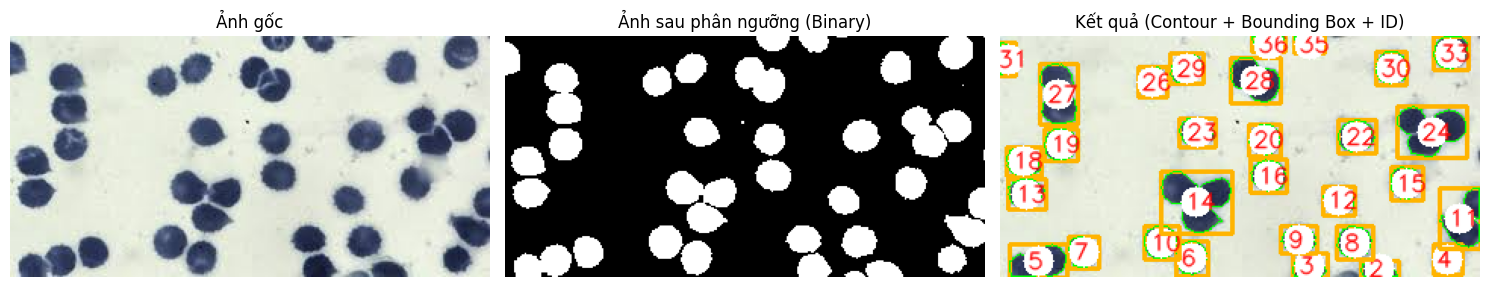

In [3]:
import cv2
import numpy as np
import csv
import matplotlib.pyplot as plt

# --- 1. Đọc và xử lý ảnh ---
img = cv2.imread('img/te_bao.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# --- 2. Đánh nhãn vùng liên thông ---
num_labels, labels = cv2.connectedComponents(binary)
print("Số vùng liên thông:", num_labels - 1)

# --- 3. Tìm contour ---
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# --- 4. Vẽ contour, bounding box và xuất dữ liệu ---
output = img.copy()
results = []

for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if area < 50:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    cx, cy = x + w//2, y + h//2

    # Bounding box (màu xanh dương nhạt)
    cv2.rectangle(output, (x, y), (x+w, y+h), (0, 180, 255), 2)
    
    # Contour (màu xanh lá)
    cv2.drawContours(output, [cnt], -1, (0, 255, 0), 1)

    # Ghi số thứ tự (màu đỏ đậm, nền trắng)
    cv2.circle(output, (cx, cy), 10, (255, 255, 255), -1)
    cv2.putText(output, str(i+1), (cx-7, cy+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)

    results.append([i+1, cx, cy, int(area)])

# --- 5. Lưu kết quả ra CSV ---
with open('cells_detected.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['ID', 'cx', 'cy', 'area'])
    writer.writerows(results)

print(f"Đã lưu {len(results)} đối tượng vào cells_detected.csv")

# --- 6. Hiển thị kết quả ---
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Ảnh sau phân ngưỡng (Binary)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Kết quả (Contour + Bounding Box + ID)")
plt.axis('off')

plt.tight_layout()
plt.show()


# bài 5 :  Biểu diễn biên – Boundary Representation


Độ dài contour OpenCV: 34
Độ dài chain code: 33
Ví dụ 20 phần tử đầu của chain code: [5, 4, 4, 4, 5, 4, 5, 4, 0, 0, 7, 3, 1, 0, 1, 0, 0, 1, 0, 0]


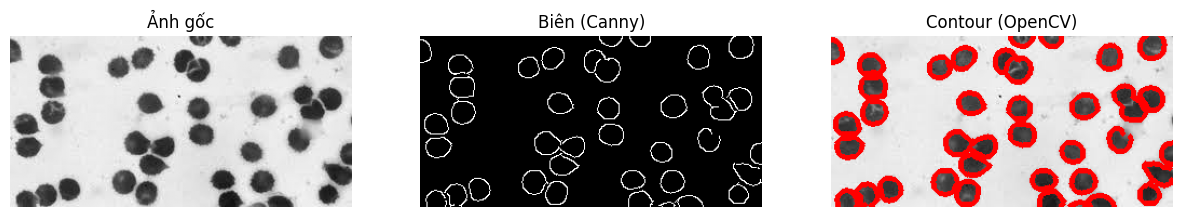

In [ ]:
# ===============================
# Biểu diễn và mã hóa biên đối tượng bằng Chain Code (Freeman code)
# ===============================

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img/te_bao.jpg", cv2.IMREAD_GRAYSCALE)

# Làm mờ và phát hiện biên
blur = cv2.GaussianBlur(img, (7, 7), 0)
edges = cv2.Canny(blur, 100, 200)

# ---- 2. Tìm contour bằng OpenCV ----
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# Vẽ contour đầu tiên
img_contour = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_contour, contours, -1, (255,0, 0), 3)


# ---- 3. Tạo Freeman Chain Code ----
# Định nghĩa hướng Freeman (8 hướng)
# Hướng: 0:→, 1:↗, 2:↑, 3:↖, 4:←, 5:↙, 6:↓, 7:↘
directions = [(1, 0), (1, -1), (0, -1), (-1, -1),
              (-1, 0), (-1, 1), (0, 1), (1, 1)]

def freeman_chain_code(contour):
    """Trả về chuỗi mã chain code cho contour."""
    contour = contour.squeeze()
    chain_code = []
    for i in range(len(contour) - 1):
        dy = contour[i+1][1] - contour[i][1]
        dx = contour[i+1][0] - contour[i][0]
        for code, (x_dir, y_dir) in enumerate(directions):
            if (dx, dy) == (x_dir, y_dir):
                chain_code.append(code)
                break
    return chain_code

# Lấy contour đầu tiên
contour = contours[0]
chain_code = freeman_chain_code(contour)

# ---- 4. So sánh với contour của OpenCV ----
print("Độ dài contour OpenCV:", len(contour))
print("Độ dài chain code:", len(chain_code))
print("Ví dụ 20 phần tử đầu của chain code:", chain_code[:20])

# ---- 5. Hiển thị kết quả ----
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Ảnh gốc')

ax[1].imshow(edges, cmap='gray')
ax[1].set_title('Biên (Canny)')

ax[2].imshow(img_contour)
ax[2].set_title('Contour (OpenCV)')

for a in ax: a.axis('off')
plt.show()